# 선적분의 기본정리에 대한 직관, 다변수 함수의 최적화와 곡면 (뉴진수 11강)-12강 3기 11강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y, t = sp.symbols("x y t", real=True)

## 1. 이차 형식은 왜 갑자기 나오는가
이차 형식 $a\,dx^2+2h\,dx\,dy+b\,dy^2$ 는 Hessian 행렬과 벡터곱으로 같은 식입니다:
$\begin{pmatrix}dx&dy\end{pmatrix}\begin{pmatrix}f_{xx}&f_{xy}\\ f_{yx}&f_{yy}\end{pmatrix}\begin{pmatrix}dx\\dy\end{pmatrix}$.

In [2]:
dx, dy, a, h, b = sp.symbols("dx dy a h b", real=True)
H = sp.Matrix([[a, h], [h, b]])
quad_matrix = (sp.Matrix([[dx, dy]]) * H * sp.Matrix([dx, dy]))[0]
quad_form = a * dx**2 + 2 * h * dx * dy + b * dy**2
print("(dx dy) H (dx dy)^T =", sp.expand(quad_matrix))
print("a dx^2 + 2h dx dy + b dy^2 =", sp.expand(quad_form))
print("equal? ", sp.simplify(quad_matrix - quad_form) == 0)

(dx dy) H (dx dy)^T = a*dx**2 + b*dy**2 + 2*dx*dy*h
a dx^2 + 2h dx dy + b dy^2 = a*dx**2 + b*dy**2 + 2*dx*dy*h
equal?  True


## 3. $df=f_xdx+f_ydy$ 를 기하적으로 읽기
작은 이동 $(dx,dy)$ 에 대한 1차 근사 $df = \nabla f\cdot(dx,dy)$ 가
실제 함수값 변화와 얼마나 잘 맞는지, $f=x^2+y^2$ 의 한 점에서 확인합니다.

In [3]:
f = x**2 + y**2
fx, fy = sp.diff(f, x), sp.diff(f, y)
p = {x: 1.0, y: 0.5}                       # base point
print("grad f =", (fx, fy), " at p ->", (float(fx.subs(p)), float(fy.subs(p))))
for d in [0.5, 0.1, 0.01]:
    hx, hy = d, -0.5 * d
    df_lin = float(fx.subs(p)) * hx + float(fy.subs(p)) * hy
    df_true = float(f.subs({x: p[x] + hx, y: p[y] + hy})) - float(f.subs(p))
    print(f"  step={d:5.2f}:  df(linear)={df_lin:+.5f}   df(true)={df_true:+.5f}   error={df_true-df_lin:+.5f}")

grad f = (2*x, 2*y)  at p -> (2.0, 1.0)
  step= 0.50:  df(linear)=+0.75000   df(true)=+1.06250   error=+0.31250
  step= 0.10:  df(linear)=+0.15000   df(true)=+0.16250   error=+0.01250
  step= 0.01:  df(linear)=+0.01500   df(true)=+0.01513   error=+0.00013


## 4. 테일러 전개와 Hessian이 만나는 자리
임계점에서는 1차항이 사라지고 $f(p+h)\approx f(p)+\tfrac12 h^\top H_f(p)\,h$.
2변수 판별식 $D=f_{xx}f_{yy}-f_{xy}^2$ 와 $f_{xx}$ 의 부호로 극소/극대/안장점을 판정합니다.

In [4]:
def classify(expr):
    fx, fy = sp.diff(expr, x), sp.diff(expr, y)
    crits = sp.solve([fx, fy], [x, y], dict=True)
    fxx, fyy, fxy = sp.diff(expr, x, 2), sp.diff(expr, y, 2), sp.diff(expr, x, y)
    out = []
    for cp in crits:
        D = (fxx * fyy - fxy**2).subs(cp)
        sxx = fxx.subs(cp)
        kind = ("saddle" if D < 0 else "local min" if sxx > 0 else
                "local max" if sxx < 0 else "inconclusive")
        out.append((cp, sp.nsimplify(D), kind))
    return out

for g in [x**2 + y**2, -(x**2 + y**2), x**2 - y**2]:
    print(f"f = {g}")
    for cp, D, kind in classify(g):
        print(f"    crit {cp}   D={D}   -> {kind}")

f = x**2 + y**2
    crit {x: 0, y: 0}   D=4   -> local min
f = -x**2 - y**2
    crit {x: 0, y: 0}   D=4   -> local max
f = x**2 - y**2
    crit {x: 0, y: 0}   D=-4   -> saddle


## 10. 그래디언트장의 선적분과 경로 독립성
$f=x^2+y^2$, $\nabla f=(2x,2y)$. $A=(-1,0)\to B=(2,1)$ 을 잇는 **두 다른 경로**의
선적분 $\int \nabla f(\mathbf r)\cdot\mathbf r'\,dt$ 이 모두 $f(B)-f(A)$ 와 같음을 SymPy로 확인합니다.

In [5]:
f = x**2 + y**2
grad = sp.Matrix([sp.diff(f, x), sp.diff(f, y)])
A, B = (-1, 0), (2, 1)
fB_minus_fA = f.subs({x: B[0], y: B[1]}) - f.subs({x: A[0], y: A[1]})

paths = {
    "straight line": (sp.Matrix([-1 + 3 * t, t]), (0, 1)),
    "parabola bend": (sp.Matrix([-1 + 3 * t, t**2]), (0, 1)),
}
print("f(B) - f(A) =", fB_minus_fA)
for name, (r, (t0, t1)) in paths.items():
    integrand = (grad.subs({x: r[0], y: r[1]}).T * sp.diff(r, t))[0]
    val = sp.integrate(integrand, (t, t0, t1))
    print(f"  line integral along {name:14s} = {sp.simplify(val)}")

f(B) - f(A) = 4
  line integral along straight line  = 4
  line integral along parabola bend  = 4


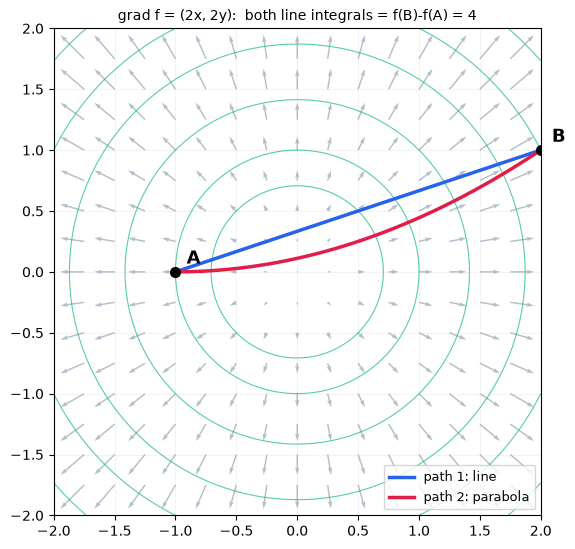

In [6]:
fig, ax = plt.subplots(figsize=(6, 5.6))
xs, ys = np.meshgrid(np.linspace(-2, 2, 17), np.linspace(-2, 2, 17))
ax.quiver(xs, ys, 2 * xs, 2 * ys, color="#94a3b8", alpha=0.7,
          angles="xy", scale_units="xy", scale=18, width=0.003)
levels = [0.5, 1, 2, 3.5, 5, 7]
cs = np.linspace(-2, 2, 200)
gx, gy = np.meshgrid(cs, cs)
ax.contour(gx, gy, gx**2 + gy**2, levels=levels, colors="#10b981", linewidths=0.8, alpha=0.7)
tt = np.linspace(0, 1, 100)
ax.plot(-1 + 3 * tt, tt, color="#2563eb", lw=2.5, label="path 1: line")
ax.plot(-1 + 3 * tt, tt**2, color="#e11d48", lw=2.5, label="path 2: parabola")
for P, name in [(A, "A"), (B, "B")]:
    ax.plot(*P, "ko", ms=7)
    ax.annotate(name, P, textcoords="offset points", xytext=(8, 6), fontsize=13, weight="bold")
ax.set_title(f"grad f = (2x, 2y):  both line integrals = f(B)-f(A) = {int(fB_minus_fA)}", fontsize=10)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.15)
fig.tight_layout()
plt.show()

## 11. 폐경로를 돌면 왜 $0$이 되는가
같은 점으로 돌아오는 폐경로 (단위원) 위에서 $\nabla f$ 를 적분하면
$f(\text{끝점})-f(\text{시작점})=0$. 그래디언트장의 순환(circulation)은 0입니다.

In [7]:
r = sp.Matrix([sp.cos(t), sp.sin(t)])              # closed loop: unit circle
integrand = (grad.subs({x: r[0], y: r[1]}).T * sp.diff(r, t))[0]
loop = sp.integrate(sp.simplify(integrand), (t, 0, 2 * sp.pi))
print("closed-loop integral of grad f around unit circle =", loop)

# contrast: a NON-gradient field F=(-y, x) has nonzero circulation
P, Q = -r[1], r[0]
F = sp.Matrix([P, Q])
loop_F = sp.integrate((F.T * sp.diff(r, t))[0], (t, 0, 2 * sp.pi))
print("closed-loop integral of F=(-y, x) (not a gradient) =", loop_F, " (nonzero -> no potential)")

closed-loop integral of grad f around unit circle = 0
closed-loop integral of F=(-y, x) (not a gradient) = 2*pi  (nonzero -> no potential)
